<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/Expt7_Text_Preprocessing_Word2Vec_24BAD121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPT NO: 7 — TEXT PREPROCESSING AND EMBEDDING GENERATION USING NLP LIBRARIES
**Name:** SWASTHIKA M  
**Roll No:** 24BAD121  
**Date:** 09.10.2026  

**Aim:** To perform text preprocessing using NLTK and generate word embeddings using Gensim Word2Vec to analyze semantic relationships between words.

In [1]:
# Install / import libraries
!pip install -q gensim nltk numpy

import nltk, string, numpy as np
from nltk.corpus import brown, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import FreqDist
from gensim.models import Word2Vec

for pkg in ['brown', 'punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

ROLL_NO = "24BAD121"
NAME = "SWASTHIKA M"
print(f"Name: {NAME} | Roll No: {ROLL_NO}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 63.5 MB/s eta 0:00:00
Name: SWASTHIKA M | Roll No: 24BAD121


## PART A: DATASET PREPARATION AND TEXT PREPROCESSING

In [2]:
print(f"Roll No: {ROLL_NO}")
print("Part A: Dataset Preparation and Text Preprocessing\n")

# 1. Load Brown Corpus and select a category
category = 'news'
print("Available categories:", brown.categories())
print("Selected category   :", category)

# 2. Examine sample sentences
raw_sents = brown.sents(categories=category)
print("\nTotal sentences in category:", len(raw_sents))
for i in range(3):
    print(f"Sample {i+1}:", " ".join(raw_sents[i]))

Roll No: 24BAD121
Part A: Dataset Preparation and Text Preprocessing

Available categories: ['adventure', 'belles_lettres', 'editorial', 'fiction', 'government', 'hobbies', 'humor', 'learned', 'lore', 'mystery', 'news', 'religion', 'reviews', 'romance', 'science_fiction']
Selected category   : news

Total sentences in category: 4623
Sample 1: The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .
Sample 2: The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .
Sample 3: The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities '' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr. .


In [3]:
print(f"Roll No: {ROLL_NO}")

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(sentence_text):
    # Lowercase
    text = sentence_text.lower()
    # Word tokenization (NLTK)
    tokens = word_tokenize(text)
    # Remove punctuation / non-alphabetic tokens
    tokens = [t for t in tokens if t not in string.punctuation and t.isalpha()]
    # Remove stop words
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatization (WordNet)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

original_sentences = [" ".join(s) for s in raw_sents]
processed_sentences = [preprocess(s) for s in original_sentences]
processed_sentences = [s for s in processed_sentences if len(s) > 0]

# Display original vs preprocessed text
for i in range(5):
    print(f"\n--- Sentence {i+1} ---")
    print("Original    :", original_sentences[i])
    print("Preprocessed:", processed_sentences[i])
print("\nTotal preprocessed sentences:", len(processed_sentences))

Roll No: 24BAD121

--- Sentence 1 ---
Original    : The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence '' that any irregularities took place .
Preprocessed: ['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularity', 'took', 'place']

--- Sentence 2 ---
Original    : The jury further said in term-end presentments that the City Executive Committee , which had over-all charge of the election , `` deserves the praise and thanks of the City of Atlanta '' for the manner in which the election was conducted .
Preprocessed: ['jury', 'said', 'presentment', 'city', 'executive', 'committee', 'charge', 'election', 'deserves', 'praise', 'thanks', 'city', 'atlanta', 'manner', 'election', 'conducted']

--- Sentence 3 ---
Original    : The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigat

## PART B: VOCABULARY GENERATION AND WORD FREQUENCY ANALYSIS

Roll No: 24BAD121
Part B: Vocabulary and Word Frequency Analysis

Total tokens   : 47682
Vocabulary size: 9896

Ten most frequent words:
said         406
year         260
would        249
new          241
state        223
one          222
last         177
two          174
first        158
president    155


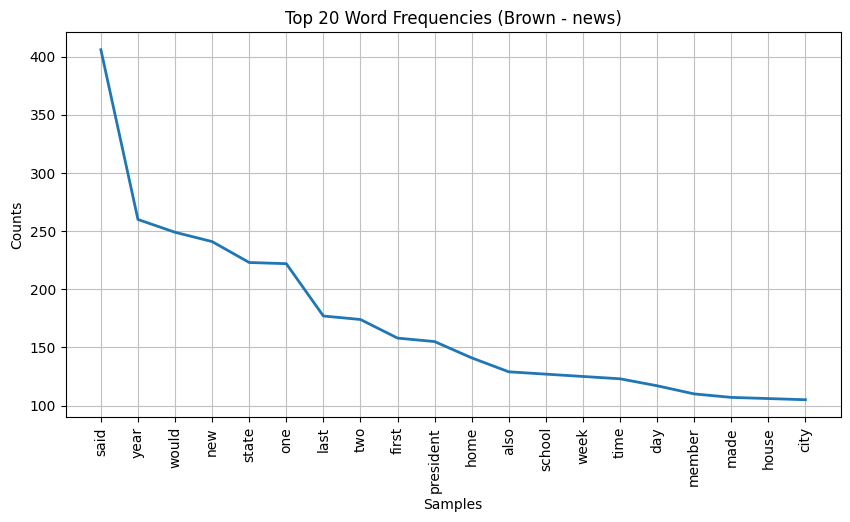


Sample tokenized sentences for Word2Vec:
['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularity', 'took', 'place']
['jury', 'said', 'presentment', 'city', 'executive', 'committee', 'charge', 'election', 'deserves', 'praise', 'thanks', 'city', 'atlanta', 'manner', 'election', 'conducted']
['term', 'jury', 'charged', 'fulton', 'superior', 'court', 'judge', 'durwood', 'pye', 'investigate', 'report', 'possible', 'irregularity', 'primary', 'ivan', 'allen']


In [4]:
print(f"Roll No: {ROLL_NO}")
print("Part B: Vocabulary and Word Frequency Analysis\n")

# Flatten all tokens
all_tokens = [w for sent in processed_sentences for w in sent]

# Vocabulary
vocabulary = sorted(set(all_tokens))
print("Total tokens   :", len(all_tokens))
print("Vocabulary size:", len(vocabulary))

# Frequency distribution
fdist = FreqDist(all_tokens)

print("\nTen most frequent words:")
for word, count in fdist.most_common(10):
    print(f"{word:<12} {count}")

# Plot frequency distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
fdist.plot(20, title="Top 20 Word Frequencies (Brown - news)")
plt.show()

# Sentences prepared for Word2Vec
print("\nSample tokenized sentences for Word2Vec:")
for s in processed_sentences[:3]:
    print(s)

## PART C: WORD EMBEDDING GENERATION USING WORD2VEC

In [5]:
print(f"Roll No: {ROLL_NO}")
print("Part C: Word2Vec (Skip-gram)\n")

model = Word2Vec(
    sentences=processed_sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window size
    min_count=2,       # ignore very rare words
    sg=1,              # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=20,
    seed=42
)

print("Vocabulary size in Word2Vec model:", len(model.wv))

# Embedding vector for selected words
for word in ['president', 'government']:
    if word in model.wv:
        vec = model.wv[word]
        print(f"\nWord: '{word}'")
        print("Vector shape :", vec.shape)
        print("Dimensions   :", len(vec))
        print("First 10 values:", np.round(vec[:10], 4))

# Five most similar words
target = 'president'
print(f"\nFive most similar words to '{target}':")
for w, score in model.wv.most_similar(target, topn=5):
    print(f"{w:<15} {score:.4f}")

Roll No: 24BAD121
Part C: Word2Vec (Skip-gram)

Vocabulary size in Word2Vec model: 5164

Word: 'president'
Vector shape : (100,)
Dimensions   : 100
First 10 values: [-0.3344 -0.2388 -0.0115  0.6592 -0.1156  0.1271  0.2089  0.007   0.1399
 -0.7094]

Word: 'government'
Vector shape : (100,)
Dimensions   : 100
First 10 values: [ 0.0969  0.055   0.166   0.2216  0.2644 -0.1437  0.3479  0.5072  0.1108
 -0.711 ]

Five most similar words to 'president':
inauguration    0.7495
stevenson       0.7402
vice            0.7333
jacqueline      0.7251
adviser         0.7115


## PART D: WORD SIMILARITY ANALYSIS

In [6]:
print(f"Roll No: {ROLL_NO}")
print("Part D: Cosine Similarity of Word Pairs\n")

candidate_pairs = [
    ('president', 'government'),
    ('city', 'county'),
    ('school', 'student'),
    ('house', 'committee'),
    ('state', 'government'),
    ('man', 'woman'),
]
# keep only pairs whose words exist in the vocabulary, take three
pairs = [p for p in candidate_pairs if p[0] in model.wv and p[1] in model.wv][:3]

scores = {}
for w1, w2 in pairs:
    sim = model.wv.similarity(w1, w2)   # cosine similarity
    scores[(w1, w2)] = sim
    print(f"Cosine similarity ({w1}, {w2}) = {sim:.4f}")

best = max(scores, key=scores.get)
print(f"\nMost similar pair: {best} with score {scores[best]:.4f}")

# Manual verification of cosine similarity using NumPy
a, b = model.wv[best[0]], model.wv[best[1]]
manual = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(f"Manual cosine check: {manual:.4f}")

Roll No: 24BAD121
Part D: Cosine Similarity of Word Pairs

Cosine similarity (president, government) = 0.2820
Cosine similarity (city, county) = 0.1102
Cosine similarity (school, student) = 0.6618

Most similar pair: ('school', 'student') with score 0.6618
Manual cosine check: 0.6618
